# 🧠 NeuroFormer: Transformer Walkthrough

This notebook demonstrates the implementation of the core Transformer architecture from scratch, based on the **"Attention Is All You Need"** paper (Vaswani et al., 2017).

We will walk through the key components:
1. Positional Encoding
2. Scaled Dot-Product Attention
3. Multi-Head Attention
4. Encoder / Decoder Assembly
5. Full Model Instantiation
6. Copy-Task Validation

In [1]:
import sys
import os
sys.path.insert(0, os.path.dirname(os.getcwd()))

import torch
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from src.transformer.attention import scaled_dot_product_attention, MultiHeadAttention
from src.transformer.embeddings import TokenEmbedding, PositionalEncoding
from src.transformer.feed_forward import PositionwiseFeedForward
from src.transformer.encoder import Encoder
from src.transformer.decoder import Decoder
from src.transformer.transformer import Transformer
from src.transformer.utils import generate_causal_mask, generate_padding_mask

## 1. Positional Encoding (Paper Section 3.5)

Since Transformers do not have recurrence or convolution, they need positional encodings to inject information about the relative or absolute position of the tokens in the sequence.

$$PE_{(pos, 2i)} = \sin\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$
$$PE_{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$

The paper chose sinusoidal encodings because for any fixed offset $k$, $PE_{pos+k}$ can be represented as a linear function of $PE_{pos}$, allowing the model to learn relative positions.

PE buffer shape: torch.Size([1, 100, 512])


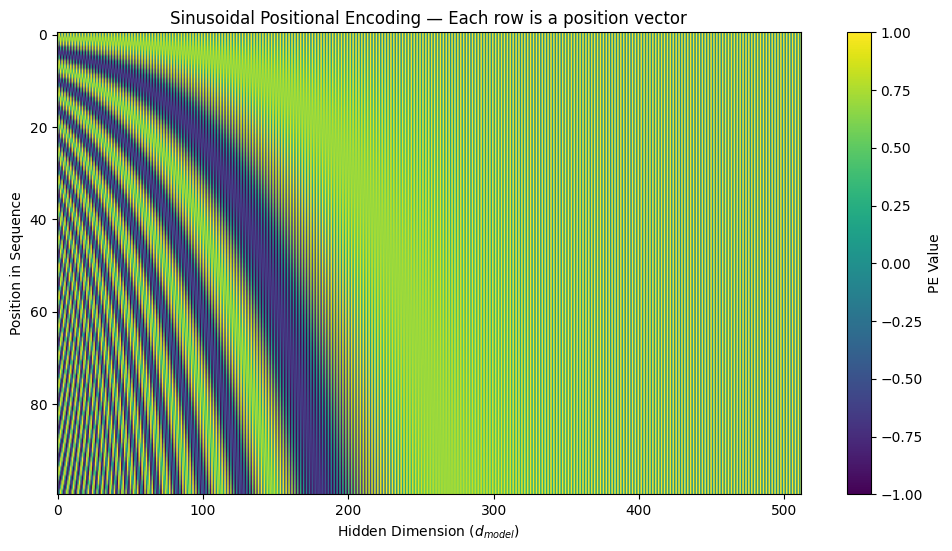

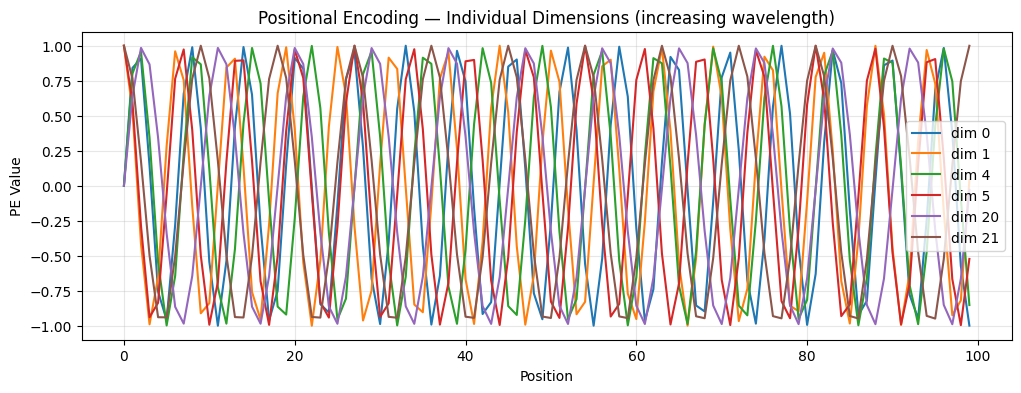

In [2]:
d_model = 512
max_len = 100
pe = PositionalEncoding(d_model=d_model, max_len=max_len, dropout=0.0)

# The PE matrix is stored as a buffer: (1, max_len, d_model)
pe_matrix = pe.pe.squeeze(0).numpy()
print(f"PE buffer shape: {pe.pe.shape}")

plt.figure(figsize=(12, 6))
plt.imshow(pe_matrix, aspect='auto', cmap='viridis')
plt.colorbar(label='PE Value')
plt.xlabel('Hidden Dimension ($d_{model}$)')
plt.ylabel('Position in Sequence')
plt.title('Sinusoidal Positional Encoding — Each row is a position vector')
plt.show()

# Plot individual dimensions to see the sinusoidal patterns
plt.figure(figsize=(12, 4))
for dim in [0, 1, 4, 5, 20, 21]:
    plt.plot(pe_matrix[:, dim], label=f'dim {dim}')
plt.xlabel('Position')
plt.ylabel('PE Value')
plt.title('Positional Encoding — Individual Dimensions (increasing wavelength)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 2. Scaled Dot-Product Attention (Paper Section 3.2.1)

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

The scaling factor $1/\sqrt{d_k}$ prevents the dot products from growing too large and pushing the softmax into regions with extremely small gradients.

Q shape: torch.Size([1, 1, 8, 64])
Output shape: torch.Size([1, 1, 8, 64])
Attention weights shape: torch.Size([1, 1, 8, 8])

Attention weights sum per row (should be ~1.0): [1.0000001 1.        1.0000001 1.        0.9999999 1.        1.
 1.0000001]


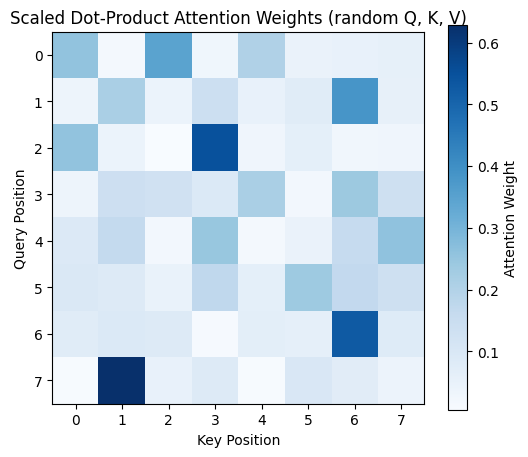

In [3]:
# Simulate Q, K, V for a single head
batch_size = 1
n_heads = 1
seq_len = 8
d_k = 64

Q = torch.randn(batch_size, n_heads, seq_len, d_k)
K = torch.randn(batch_size, n_heads, seq_len, d_k)
V = torch.randn(batch_size, n_heads, seq_len, d_k)

output, attn_weights = scaled_dot_product_attention(Q, K, V)

print(f"Q shape: {Q.shape}")
print(f"Output shape: {output.shape}")
print(f"Attention weights shape: {attn_weights.shape}")
print(f"\nAttention weights sum per row (should be ~1.0): {attn_weights[0, 0].sum(dim=-1).numpy()}")

# Visualize the attention weights
plt.figure(figsize=(6, 5))
plt.imshow(attn_weights[0, 0].numpy(), cmap='Blues')
plt.colorbar(label='Attention Weight')
plt.xlabel('Key Position')
plt.ylabel('Query Position')
plt.title('Scaled Dot-Product Attention Weights (random Q, K, V)')
plt.show()

## 3. Multi-Head Attention (Paper Section 3.2.2)

Instead of performing a single attention function, we project the queries, keys, and values $h$ times with different learned projections, perform attention in parallel, and concatenate the results.

$$\text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1, \ldots, \text{head}_h)W^O$$

Paper defaults: $h=8$, $d_k = d_v = d_{model}/h = 64$.

In [4]:
# Create Multi-Head Attention with paper defaults
mha = MultiHeadAttention(d_model=512, num_heads=8, dropout=0.1)
print(mha)
print(f"\nd_k per head: {mha.d_k}")

seq_len = 10
batch_size = 2
x = torch.randn(batch_size, seq_len, 512)

# Self-attention: Query, Key, and Value are all the same (x)
out = mha(x, x, x)
print(f"\nInput shape:  {x.shape}")
print(f"Output shape: {out.shape}")
print(f"Stored attention weights shape: {mha.attention_weights.shape}")
print(f"  → (batch={batch_size}, heads=8, seq_len={seq_len}, seq_len={seq_len})")

MultiHeadAttention(
  (W_q): Linear(in_features=512, out_features=512, bias=True)
  (W_k): Linear(in_features=512, out_features=512, bias=True)
  (W_v): Linear(in_features=512, out_features=512, bias=True)
  (W_o): Linear(in_features=512, out_features=512, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
)

d_k per head: 64

Input shape:  torch.Size([2, 10, 512])
Output shape: torch.Size([2, 10, 512])
Stored attention weights shape: torch.Size([2, 8, 10, 10])
  → (batch=2, heads=8, seq_len=10, seq_len=10)


## 4. Causal Masking (Decoder)

In the decoder, we prevent positions from attending to subsequent positions. This is done with a causal (look-ahead) mask — an upper-triangular matrix of `-inf` values.

Causal mask (1 = can attend, 0 = blocked):
tensor([[1., 0., 0., 0., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0., 0., 0., 0.],
        [1., 1., 1., 0., 0., 0., 0., 0.],
        [1., 1., 1., 1., 0., 0., 0., 0.],
        [1., 1., 1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1., 1., 1., 1.]])


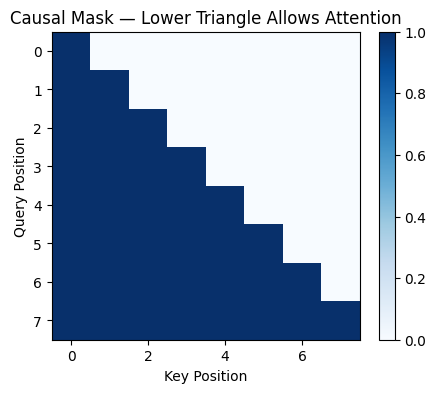

In [5]:
causal = generate_causal_mask(8)
print("Causal mask (1 = can attend, 0 = blocked):")
print(causal.squeeze())

plt.figure(figsize=(5, 4))
plt.imshow(causal.squeeze().numpy(), cmap='Blues')
plt.title('Causal Mask — Lower Triangle Allows Attention')
plt.xlabel('Key Position')
plt.ylabel('Query Position')
plt.colorbar()
plt.show()

## 5. Full Transformer Model

Let's assemble the complete Encoder-Decoder model using our `build_model` factory.

In [6]:
# Build the base model (paper Table 3)
model = Transformer.build_model(
    src_vocab_size=1000,
    tgt_vocab_size=1000,
    variant="base",  # d_model=512, num_heads=8, num_layers=6, d_ff=2048
)

total_params = model.count_parameters()
print(f"Total trainable parameters: {total_params:,}")
print(f"\nModel architecture:")
print(model)

# Quick forward pass test
src = torch.randint(1, 1000, (2, 20))  # (batch=2, src_len=20)
tgt = torch.randint(1, 1000, (2, 15))  # (batch=2, tgt_len=15)
output = model(src, tgt)
print(f"\nForward pass: src {src.shape} + tgt {tgt.shape} → output {output.shape}")
print(f"Output contains logits over vocabulary: {output.shape[-1]} classes")

Total trainable parameters: 44,653,544

Model architecture:
Transformer(
  (src_embedding): TokenEmbedding(
    (embedding): Embedding(1000, 512)
  )
  (tgt_embedding): TokenEmbedding(
    (embedding): Embedding(1000, 512)
  )
  (positional_encoding): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): Encoder(
    (layers): ModuleList(
      (0-5): 6 x EncoderLayer(
        (self_attention): MultiHeadAttention(
          (W_q): Linear(in_features=512, out_features=512, bias=True)
          (W_k): Linear(in_features=512, out_features=512, bias=True)
          (W_v): Linear(in_features=512, out_features=512, bias=True)
          (W_o): Linear(in_features=512, out_features=512, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (feed_forward): PositionwiseFeedForward(
          (linear_1): Linear(in_features=512, out_features=2048, bias=True)
          (linear_2): Linear(in_features=2048, out_features=512, bias=True)
          (d


Forward pass: src torch.Size([2, 20]) + tgt torch.Size([2, 15]) → output torch.Size([2, 15, 1000])
Output contains logits over vocabulary: 1000 classes


## 6. Copy-Task Validation

To verify the architecture is correct, we train the model on a trivial copy task: the model must learn to output the exact same sequence it receives as input. If the architecture is wired correctly, it should achieve ~100% accuracy quickly.

Run the full copy-task validation with:
```bash
python scripts/train_translation.py
```

A correctly implemented Transformer should converge to near-zero loss within a few epochs on this task.